# Vehicle Fuel Efficiency Prediction using K-Nearest Neighbors (KNN)

## Project Overview

This project develops and evaluates a machine learning pipeline for predicting vehicle fuel efficiency (MPG) using the Auto MPG dataset.

The workflow includes data loading, data quality assessment, exploratory data analysis (EDA), preprocessing, cross-validation, model training, model comparison, residual diagnostics, and artifact generation for deployment.

## Objectives

- Understand the relationships between vehicle characteristics and fuel efficiency.
- Identify the most influential features affecting MPG.
- Train and evaluate KNN regression models.
- Compare KNN performance with a Linear Regression baseline.
- Select the best-performing model based on predictive accuracy.
- Save model artifacts for reproducible deployment.

## Success Metrics

Model performance is evaluated using:

- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

The final selected model is a distance-weighted KNN regressor.

## Data Loading

The Auto MPG dataset is loaded into a pandas DataFrame for analysis.

The dataset contains vehicle characteristics including cylinders, displacement, horsepower, weight, acceleration, model year, and origin. The target variable is miles per gallon (MPG), which measures fuel efficiency.

Loading the data is the first step in understanding its structure and preparing it for exploratory analysis, preprocessing, model training, and evaluation.

In [10]:
# imports and load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

(392, 9)

In [12]:
# Load and prepare the dataset
colnames = ["mpg","cylinders","displacement","horsepower","weight","acceleration","year","origin","name"]

df = pd.read_csv("/content/sample_data/Auto.csv",
                  names=colnames, header=0, na_values='?')


### Findings

The dataset was successfully loaded into a pandas DataFrame. Missing values represented by "?" were automatically converted to NaN for further inspection.

## Dataset Overview

Inspect the dataset dimensions, columns, and overall structure.
Before building a machine learning model, it is important to understand the size and structure of the dataset.

In [14]:
df.shape
df.head()
df.info()
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.0+ KB
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin', 'name']


## Missing Values Analysis

Machine learning algorithms cannot directly handle missing values.

Before performing exploratory analysis and model training, we identify missing data and determine whether cleaning or imputation is required.

In [15]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,5
weight,0
acceleration,0
year,0
origin,0
name,0


### Findings

The dataset contains missing values only in the horsepower column.

A total of 5 observations have missing horsepower values, while all other variables are complete.

These missing values must be addressed before performing correlation analysis, feature scaling, and model training.

## Data Cleaning

The horsepower column contains missing values that must be handled before analysis.

The column is converted to a numeric data type, invalid values are treated as missing, and records with missing horsepower values are removed.

In [18]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

print("Missing horsepower values:", df['horsepower'].isna().sum())

df = df.dropna(subset=['horsepower']).reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)
df.isnull().sum()


Missing horsepower values: 0
Dataset shape after cleaning: (392, 9)


,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
year,0
origin,0
name,0


### Findings

Five observations containing missing horsepower values were removed.

The cleaned dataset now contains 392 observations and is ready for correlation analysis, exploratory analysis, and machine learning.

The horsepower variable contains missing values that must be handled before analysis.

The column is converted to a numeric data type, invalid values are treated as missing values, and rows containing missing horsepower observations are removed.

## Missing Values Analysis

Machine learning algorithms cannot handle missing values directly. Before training a model, it is important to identify which variables contain missing data and determine the appropriate cleaning strategy.

## Correlation Analysis

Correlation analysis helps identify relationships between vehicle characteristics and fuel efficiency (MPG).

Understanding these relationships helps justify feature selection and provides insight into which variables are most strongly associated with fuel efficiency.

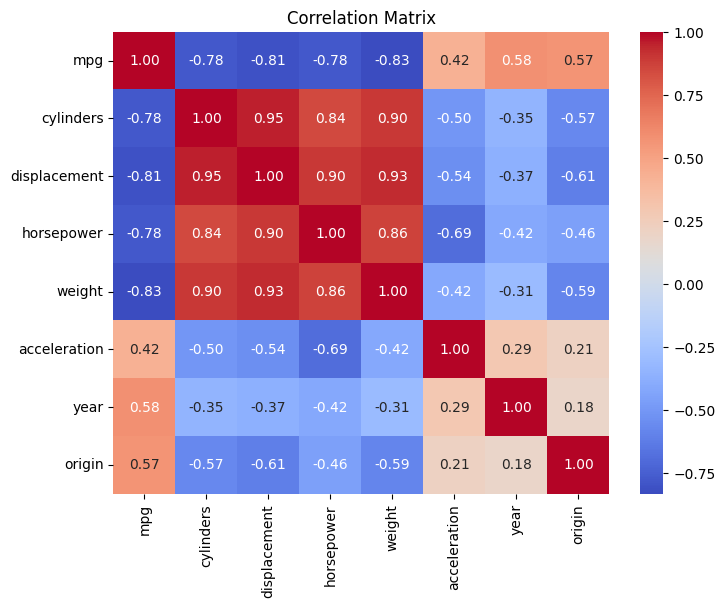

In [20]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

### Correlation Analysis Findings

Vehicle weight, displacement, horsepower, and cylinder count all show strong negative relationships with MPG.

Weight appears to be the strongest predictor of fuel efficiency, indicating that heavier vehicles generally consume more fuel and achieve lower MPG values.

Model year shows a positive correlation with MPG, suggesting that newer vehicles tend to be more fuel efficient due to improvements in vehicle technology and engine design.

These findings support the selection of displacement, horsepower, weight, acceleration, and cylinders as predictive features for the KNN regression model.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps visualize the relationships identified during correlation analysis and provides a deeper understanding of how vehicle characteristics influence fuel efficiency.

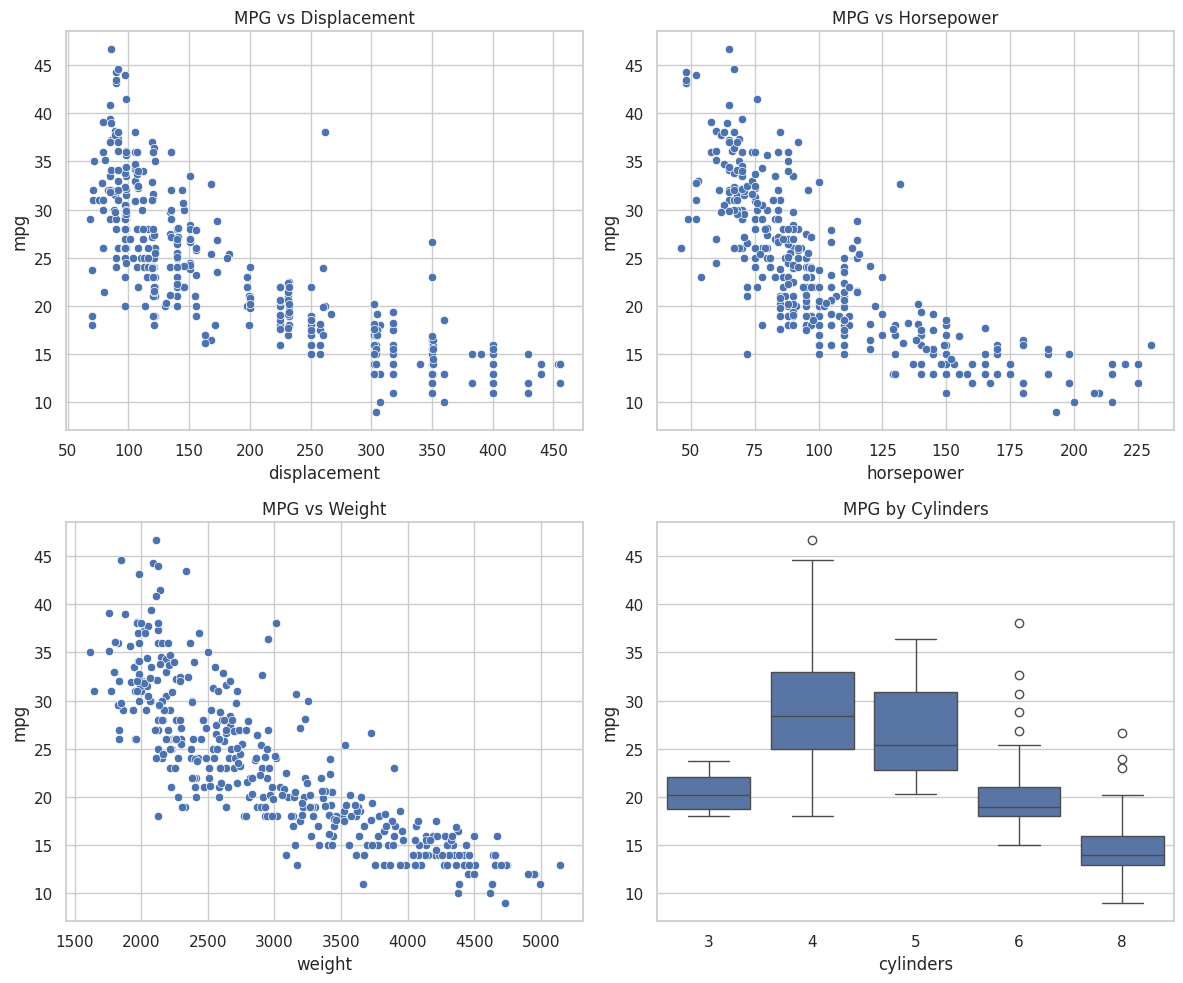

In [22]:
sns.set(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(data=df, x='displacement', y='mpg', ax=axes[0,0])
axes[0,0].set_title('MPG vs Displacement')

sns.scatterplot(data=df, x='horsepower', y='mpg', ax=axes[0,1])
axes[0,1].set_title('MPG vs Horsepower')

sns.scatterplot(data=df, x='weight', y='mpg', ax=axes[1,0])
axes[1,0].set_title('MPG vs Weight')

sns.boxplot(data=df, x='cylinders', y='mpg', ax=axes[1,1])
axes[1,1].set_title('MPG by Cylinders')

plt.tight_layout()
plt.show()

### EDA Findings

The scatterplots indicate clear negative relationships between MPG and displacement, horsepower, and vehicle weight.

Vehicles with larger engines and greater weight generally exhibit lower fuel efficiency.

The boxplot shows that vehicles with fewer cylinders tend to achieve higher MPG values than vehicles with more cylinders.

These observations further support the selected feature set and provide intuitive evidence for the relationships later captured by the machine learning model.

## Preprocessing and Train/Test Split

Based on the correlation analysis and EDA findings, displacement, horsepower, weight, acceleration, and cylinders were selected as predictor variables for vehicle fuel efficiency (MPG).

The dataset was divided into training and testing subsets using an 80/20 split. Feature scaling was performed using StandardScaler because K-Nearest Neighbors is a distance-based algorithm and is sensitive to differences in feature scales.

In [23]:
features = ['displacement','horsepower','weight','acceleration','cylinders']
X = df[features]
y = df['mpg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Findings

Five vehicle characteristics were selected as predictors of fuel efficiency.

The dataset was divided into training and testing sets using an 80/20 split, resulting in separate datasets for model training and evaluation.

The features were standardized to ensure that variables measured on different scales contribute equally to the KNN distance calculations.

## KNN Cross-Validation and Hyperparameter Tuning

The K-Nearest Neighbors algorithm requires selecting an appropriate value for K, which determines how many neighboring observations contribute to a prediction.

To identify the optimal K value, GridSearchCV with 5-fold cross-validation was used. Cross-validation helps estimate model performance on unseen data and reduces the risk of overfitting.

In [24]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

param_grid = {'n_neighbors': list(range(1,26,2))}
knn = KNeighborsRegressor()
gs = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gs.fit(X_train_scaled, y_train)
best_k = gs.best_params_['n_neighbors']
best_k, np.sqrt(-gs.best_score_)


(21, np.float64(3.893212529498033))

### Cross-Validation Findings

The optimal number of neighbors identified through 5-fold cross-validation was:

- Best K = 21
- Cross-validation RMSE = 3.89

This value was selected for the final weighted KNN model because it minimized prediction error during cross-validation.

## Model Training and Comparison

Train the selected distance-weighted KNN model using the optimal value of K obtained from cross-validation.

For comparison, a Linear Regression model is also trained and evaluated on the same test dataset.


In [25]:
from sklearn.linear_model import LinearRegression
best_k = int(best_k)
knn_w = KNeighborsRegressor(n_neighbors=best_k, weights='distance')
knn_w.fit(X_train_scaled, y_train)
lr = LinearRegression().fit(X_train_scaled, y_train)

def eval_model(model, X_test_scaled, y_test):
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return rmse, r2

print('KNN-weighted:', eval_model(knn_w, X_test_scaled, y_test))
print('LinearRegression:', eval_model(lr, X_test_scaled, y_test))


KNN-weighted: (np.float64(4.104862391938334), 0.669872595742812)
LinearRegression: (np.float64(4.235465969244854), 0.6485312110889084)


### Model Comparison Findings

The distance-weighted KNN model achieved a lower RMSE and a higher R² score than the Linear Regression baseline.

These results indicate that KNN captured non-linear relationships in the data more effectively and produced more accurate MPG predictions.

Based on the test-set performance, the distance-weighted KNN model was selected as the final model for further evaluation and artifact generation.

## Residual Analysis and Diagnostics

Residual analysis helps assess model performance by examining the distribution of prediction errors.

Ideally, residuals should be centered around zero and exhibit no strong systematic patterns. A roughly symmetric distribution suggests that the model is making unbiased predictions across the dataset.

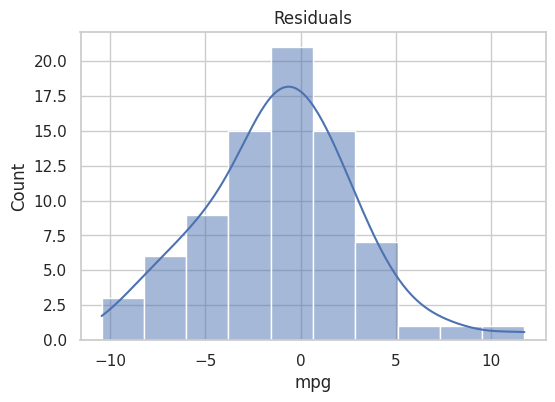

In [26]:
import matplotlib.pyplot as plt
y_pred = knn_w.predict(X_test_scaled)
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title('Residuals')
plt.show()


### Residual Diagnostics Findings

The residuals are approximately centered around zero, indicating that the model does not exhibit a strong systematic bias toward overprediction or underprediction.

Most prediction errors fall within a moderate range, although a small number of larger residuals remain. Overall, the residual distribution suggests that the selected KNN model provides a reasonable fit to the data.

## Save Artifacts

To support reproducible deployment and inference, the trained preprocessing scaler and the final weighted KNN model are saved as serialized artifacts.

These artifacts can later be loaded by external applications, including the FastAPI prediction service, without requiring the model to be retrained.

In [27]:
import os
os.makedirs('model_data', exist_ok=True)
joblib.dump(scaler, 'model_data/scaler.joblib')
joblib.dump(knn_w, 'model_data/knn_weighted.joblib')
print('Saved artifacts to model_data/')


Saved artifacts to model_data/


### Artifact Export Summary

The following artifacts were successfully exported:

- scaler.joblib: stores the fitted StandardScaler used for feature normalization.
- knn_weighted.joblib: stores the trained weighted KNN regression model.

These artifacts enable consistent preprocessing and prediction in production environments and can be loaded directly by the FastAPI application.